Dataset shape: (20640, 8)
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Model Evaluation:
MAE: 0.32754256845930246
MSE: 0.2553684927247781
RMSE: 0.5053399773665033
R2 Score: 0.8051230593157366

Actual vs Predicted Values:
   Actual Value  Predicted Value
0       0.47700         0.509500
1       0.45800         0.741610
2       5.00001         4.923257
3       2.18600         2.529610
4       2.78000         2.273690
5       1.58700         1.646920
6       1.98200         2.376050
7       1.57500         1.669320
8       3.40000         2.772971
9       4.46600         4.913459


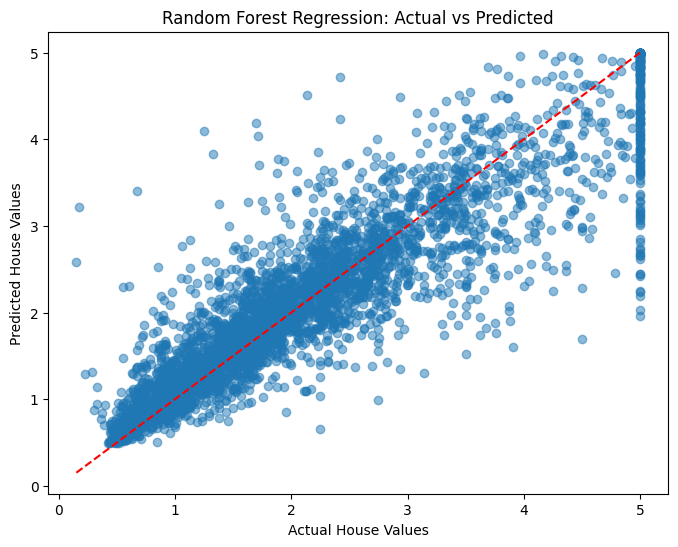

In [1]:
# Step 1: Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Step 2: Load the dataset
data = fetch_california_housing()

X = data.data
y = data.target

print("Dataset shape:", X.shape)
print("Feature names:", data.feature_names)

# Step 3: Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Step 4: Create the Random Forest Regression model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Step 5: Train the model
model.fit(X_train, y_train)

# Step 6: Make predictions
y_pred = model.predict(X_test)

# Step 7: Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# Step 8: Compare actual and predicted values
comparison = pd.DataFrame({
    "Actual Value": y_test[:10],
    "Predicted Value": y_pred[:10]
})

print("\nActual vs Predicted Values:")
print(comparison)

# Step 9: Visualize actual vs predicted values
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual House Values")
plt.ylabel("Predicted House Values")
plt.title("Random Forest Regression: Actual vs Predicted")

# Reference line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    "r--"
)

plt.show()